In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

In [2]:
# 1. LOAD DATA
# ─────────────────────────────────────────────

df_struct  = pd.read_csv("crimesense_clean.csv")
df_nlp_raw = pd.read_csv("CrimeSense_Bangalore_Dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'crimesense_clean.csv'

In [ ]:
# ─────────────────────────────────────────────
# 2. CLEAN / PREPARE NLP DATASET
# ─────────────────────────────────────────────

df_nlp = df_nlp_raw.copy()

# Normalise categories
df_nlp["category"] = df_nlp["category"].replace({"Cybercrime": "Cyber Crime", "unknown": "Other"})

# Parse dates (mixed timezone-aware and naive strings)
df_nlp["date"] = pd.to_datetime(df_nlp["date"], errors="coerce", utc=True)
df_nlp["year"] = df_nlp["date"].dt.year

In [ ]:
# ─────────────────────────────────────────────
# 3. CATEGORY MAPPING — bridge between the two datasets
# ─────────────────────────────────────────────

# Map NLP categories to the 4 structured categories for comparison
NLP_TO_STRUCTURED = {
    "Cyber Crime":       "cybercrime",
    "Women Safety":      "women_safety",
    "Harassment":        "women_safety",   # closest equivalent
    "Assault/Violence":  "violent_crime",
    "Theft/Robbery":     "property_crime",
    "Scam/Fraud":        "cybercrime",
    "Other":             "other",
}

df_nlp["mapped_category"] = df_nlp["category"].map(NLP_TO_STRUCTURED).fillna("other")

In [ ]:

# 4. SUMMARY STATS
# ─────────────────────────────────────────────

print("=" * 60)
print("CRIMESENSE — STRUCTURED vs UNSTRUCTURED COMPARISON")
print("=" * 60)

print("\n── Structured dataset ──────────────────────────────────")
print(f"  Records        : {len(df_struct):,}")
print(f"  Years          : {sorted(df_struct['year'].unique())}")
print(f"  Districts      : {df_struct['district'].nunique()}  → {df_struct['district'].unique().tolist()}")
print(f"  Crime categories: {df_struct['crime_category'].unique().tolist()}")
print(f"  Total cases    : {df_struct['cases'].sum():,}")

print("\n── NLP / Unstructured dataset ──────────────────────────")
print(f"  Records        : {len(df_nlp):,}")
print(f"  Date range     : {df_nlp['date'].min().date()} → {df_nlp['date'].max().date()}")
print(f"  Source         : {df_nlp['source'].unique().tolist()}")
print(f"  Categories     : {df_nlp['category'].unique().tolist()}")
print(f"  Severity range : {df_nlp['severity'].min()} – {df_nlp['severity'].max()}")


CRIMESENSE — STRUCTURED vs UNSTRUCTURED COMPARISON

── Structured dataset ──────────────────────────────────
  Records        : 462
  Years          : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  Districts      : 7  → ['Central', 'East', 'North', 'South', 'West', 'Whitefield', 'Yelahanka']
  Crime categories: ['property_crime', 'cybercrime', 'violent_crime', 'women_safety']
  Total cases    : 88,088

── NLP / Unstructured dataset ──────────────────────────
  Records        : 213
  Date range     : 2014-06-15 → 2026-03-09
  Source         : ['Reddit']
  Categories     : ['Women Safety', 'Other', 'Cyber Crime', 'Assault/Violence', 'Theft/Robbery', 'Harassment', 'Scam/Fraud']
  Severity range : 1 – 5


In [ ]:
# 5. COMPARISON TABLE 1 — Category share
# ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("COMPARISON 1 — Crime Category Share")
print("=" * 60)

struct_share = (df_struct.groupby("crime_category")["cases"].sum() / df_struct["cases"].sum() * 100).round(1)

nlp_mapped   = df_nlp[df_nlp["mapped_category"] != "other"]["mapped_category"].value_counts()
nlp_share    = (nlp_mapped / nlp_mapped.sum() * 100).round(1)

comp1 = pd.DataFrame({
    "Official % (cases)": struct_share,
    "NLP % (posts)":      nlp_share,
}).fillna(0)
comp1["Gap (NLP − Official)"] = (comp1["NLP % (posts)"] - comp1["Official % (cases)"]).round(1)
comp1 = comp1.sort_values("Gap (NLP − Official)", ascending=False)
print(comp1.to_string())


COMPARISON 1 — Crime Category Share
                Official % (cases)  NLP % (posts)  Gap (NLP − Official)
women_safety                   8.4           37.8                  29.4
violent_crime                  1.0            5.1                   4.1
cybercrime                    51.2           53.8                   2.6
property_crime                39.4            3.2                 -36.2


In [ ]:
# 6. COMPARISON TABLE 2 — District risk vs NLP district mentions
# ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("COMPARISON 2 — District Risk Index (Structured)")
print("=" * 60)

dist_risk = df_struct.groupby("district").agg(
    total_cases    = ("cases", "sum"),
    avg_risk_index = ("risk_index", "mean"),
    avg_detection  = ("detection_rate", "mean"),
    violent_cases  = ("cases", lambda x: df_struct.loc[x.index[df_struct.loc[x.index, "is_violent"] == 1].tolist(), "cases"].sum() if len(x) > 0 else 0),
).round(2)


COMPARISON 2 — District Risk Index (Structured)


In [ ]:
# NLP: extract district mentions from free text
district_keywords = {
    "North":      ["north bangalore", "north bang", "yelahanka", "hebbal", "jalahalli"],
    "South":      ["south bangalore", "south bang", "jayanagar", "jp nagar", "bannerghatta"],
    "East":       ["east bangalore", "east bang", "whitefield", "marathahalli", "kr puram"],
    "West":       ["west bangalore", "west bang", "rajajinagar", "vijayanagar"],
    "Central":    ["central bangalore", "majestic", "shivajinagar", "mg road", "brigade"],
    "Whitefield": ["whitefield", "varthur", "kadugodi"],
    "Yelahanka":  ["yelahanka", "bagalur", "jakkur"],
}

def count_district_mentions(text_series, keywords):
    combined = " ".join(text_series.str.lower().fillna(""))
    return sum(combined.count(kw) for kw in keywords)

nlp_district_mentions = {
    d: count_district_mentions(df_nlp["text"], kws)
    for d, kws in district_keywords.items()
}

dist_risk["nlp_mentions"] = pd.Series(nlp_district_mentions)
print(dist_risk.sort_values("avg_risk_index", ascending=False).to_string())

            total_cases  avg_risk_index  avg_detection  violent_cases  nlp_mentions
district                                                                           
North             14719           15.11          60.51           1162            11
Whitefield        12365           14.25          60.40            999             4
Yelahanka         10610           13.66          60.58            833             4
South             13957           13.32          60.58           1413            12
West              13410           13.13          60.40           1333            12
East              11231           13.08          60.49           1081             7
Central           11796           11.77          60.48           1494             2


In [ ]:
# 7. COMPARISON TABLE 3 — Severity: NLP vs Structured severity score
# ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("COMPARISON 3 — Severity: Structured score vs NLP community rating")
print("=" * 60)

struct_sev = df_struct.groupby("crime_category").agg(
    official_cases    = ("cases", "sum"),
    struct_sev_score  = ("severity_score", "mean"),
    avg_detection     = ("detection_rate", "mean"),
).round(2)

nlp_sev = df_nlp.groupby("mapped_category").agg(
    nlp_posts         = ("id", "count"),
    nlp_avg_severity  = ("severity", "mean"),
).round(2)

comp3 = struct_sev.join(nlp_sev, how="outer").fillna(0)
print(comp3.to_string())


COMPARISON 3 — Severity: Structured score vs NLP community rating
                official_cases  struct_sev_score  avg_detection  nlp_posts  nlp_avg_severity
cybercrime             45075.0              3.00           6.48         84              2.92
other                      0.0              0.00           0.00         57              2.05
property_crime         34698.0              2.37          52.47          5              4.00
violent_crime            880.0              4.67          98.54          8              5.00
women_safety            7435.0              4.20           0.00         59              3.75


In [ ]:
# 8. COMPARISON TABLE 4 — Year-over-year trend
# ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("COMPARISON 4 — Year-over-Year Trend")
print("=" * 60)

struct_yearly = df_struct.groupby("year")["cases"].sum().rename("official_cases")
nlp_yearly    = df_nlp.dropna(subset=["year"]).groupby("year")["id"].count().rename("nlp_posts")

comp4 = pd.concat([struct_yearly, nlp_yearly], axis=1)
comp4["official_cases"] = comp4["official_cases"].fillna(0).astype(int)
comp4["nlp_posts"]      = comp4["nlp_posts"].fillna(0).astype(int)
print(comp4.to_string())


COMPARISON 4 — Year-over-Year Trend
        official_cases  nlp_posts
year                             
2021.0           14504         10
2022.0           19474         11
2023.0           29710         16
2024.0           24400         39
2014.0               0          1
2016.0               0          2
2018.0               0          1
2019.0               0          5
2020.0               0          7
2025.0               0         44
2026.0               0         14


In [ ]:
# 9. UNDERREPORTING ESTIMATE
# ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("COMPARISON 5 — Underreporting Signal")
print("=" * 60)

# Women safety
ws_official  = df_struct[df_struct["crime_category"] == "women_safety"]["cases"].sum()
ws_nlp       = df_nlp[df_nlp["mapped_category"] == "women_safety"]["id"].count()
harassment   = df_nlp[df_nlp["category"] == "Harassment"]["id"].count()
total_ws_nlp = ws_nlp + harassment

# Violent crime
vc_official  = df_struct[df_struct["is_violent"] == 1]["cases"].sum()
vc_nlp       = df_nlp[df_nlp["mapped_category"] == "violent_crime"]["id"].count()

# Cybercrime
cc_official  = df_struct[df_struct["crime_category"] == "cybercrime"]["cases"].sum()
cc_nlp       = df_nlp[df_nlp["mapped_category"] == "cybercrime"]["id"].count()

# Property
pc_official  = df_struct[df_struct["crime_category"] == "property_crime"]["cases"].sum()
pc_nlp       = df_nlp[df_nlp["mapped_category"] == "property_crime"]["id"].count()

total_official = df_struct["cases"].sum()
total_nlp      = len(df_nlp)

underreport = pd.DataFrame({
    "Category":           ["Women safety + Harassment", "Violent crime", "Cybercrime", "Property crime"],
    "Official cases":     [ws_official, vc_official, cc_official, pc_official],
    "Official %":         [round(x / total_official * 100, 1) for x in [ws_official, vc_official, cc_official, pc_official]],
    "NLP posts":          [total_ws_nlp, vc_nlp, cc_nlp, pc_nlp],
    "NLP %":              [round(x / total_nlp * 100, 1) for x in [total_ws_nlp, vc_nlp, cc_nlp, pc_nlp]],
    "Gap (NLP%−Off%)":    [round((total_ws_nlp/total_nlp - ws_official/total_official)*100, 1),
                           round((vc_nlp/total_nlp       - vc_official/total_official)*100,  1),
                           round((cc_nlp/total_nlp       - cc_official/total_official)*100,  1),
                           round((pc_nlp/total_nlp       - pc_official/total_official)*100,  1)],
})
print(underreport.to_string(index=False))
print("\n  Positive gap → NLP community reports more than official records → Underreporting signal")
print("  Negative gap → Official records exceed NLP mentions")


COMPARISON 5 — Underreporting Signal
                 Category  Official cases  Official %  NLP posts  NLP %  Gap (NLP%−Off%)
Women safety + Harassment            7435         8.4         81   38.0             29.6
            Violent crime            8315         9.4          8    3.8             -5.7
               Cybercrime           45075        51.2         84   39.4            -11.7
           Property crime           34698        39.4          5    2.3            -37.0

  Positive gap → NLP community reports more than official records → Underreporting signal
  Negative gap → Official records exceed NLP mentions




Plots saved → crimesense_comparison_plots.png


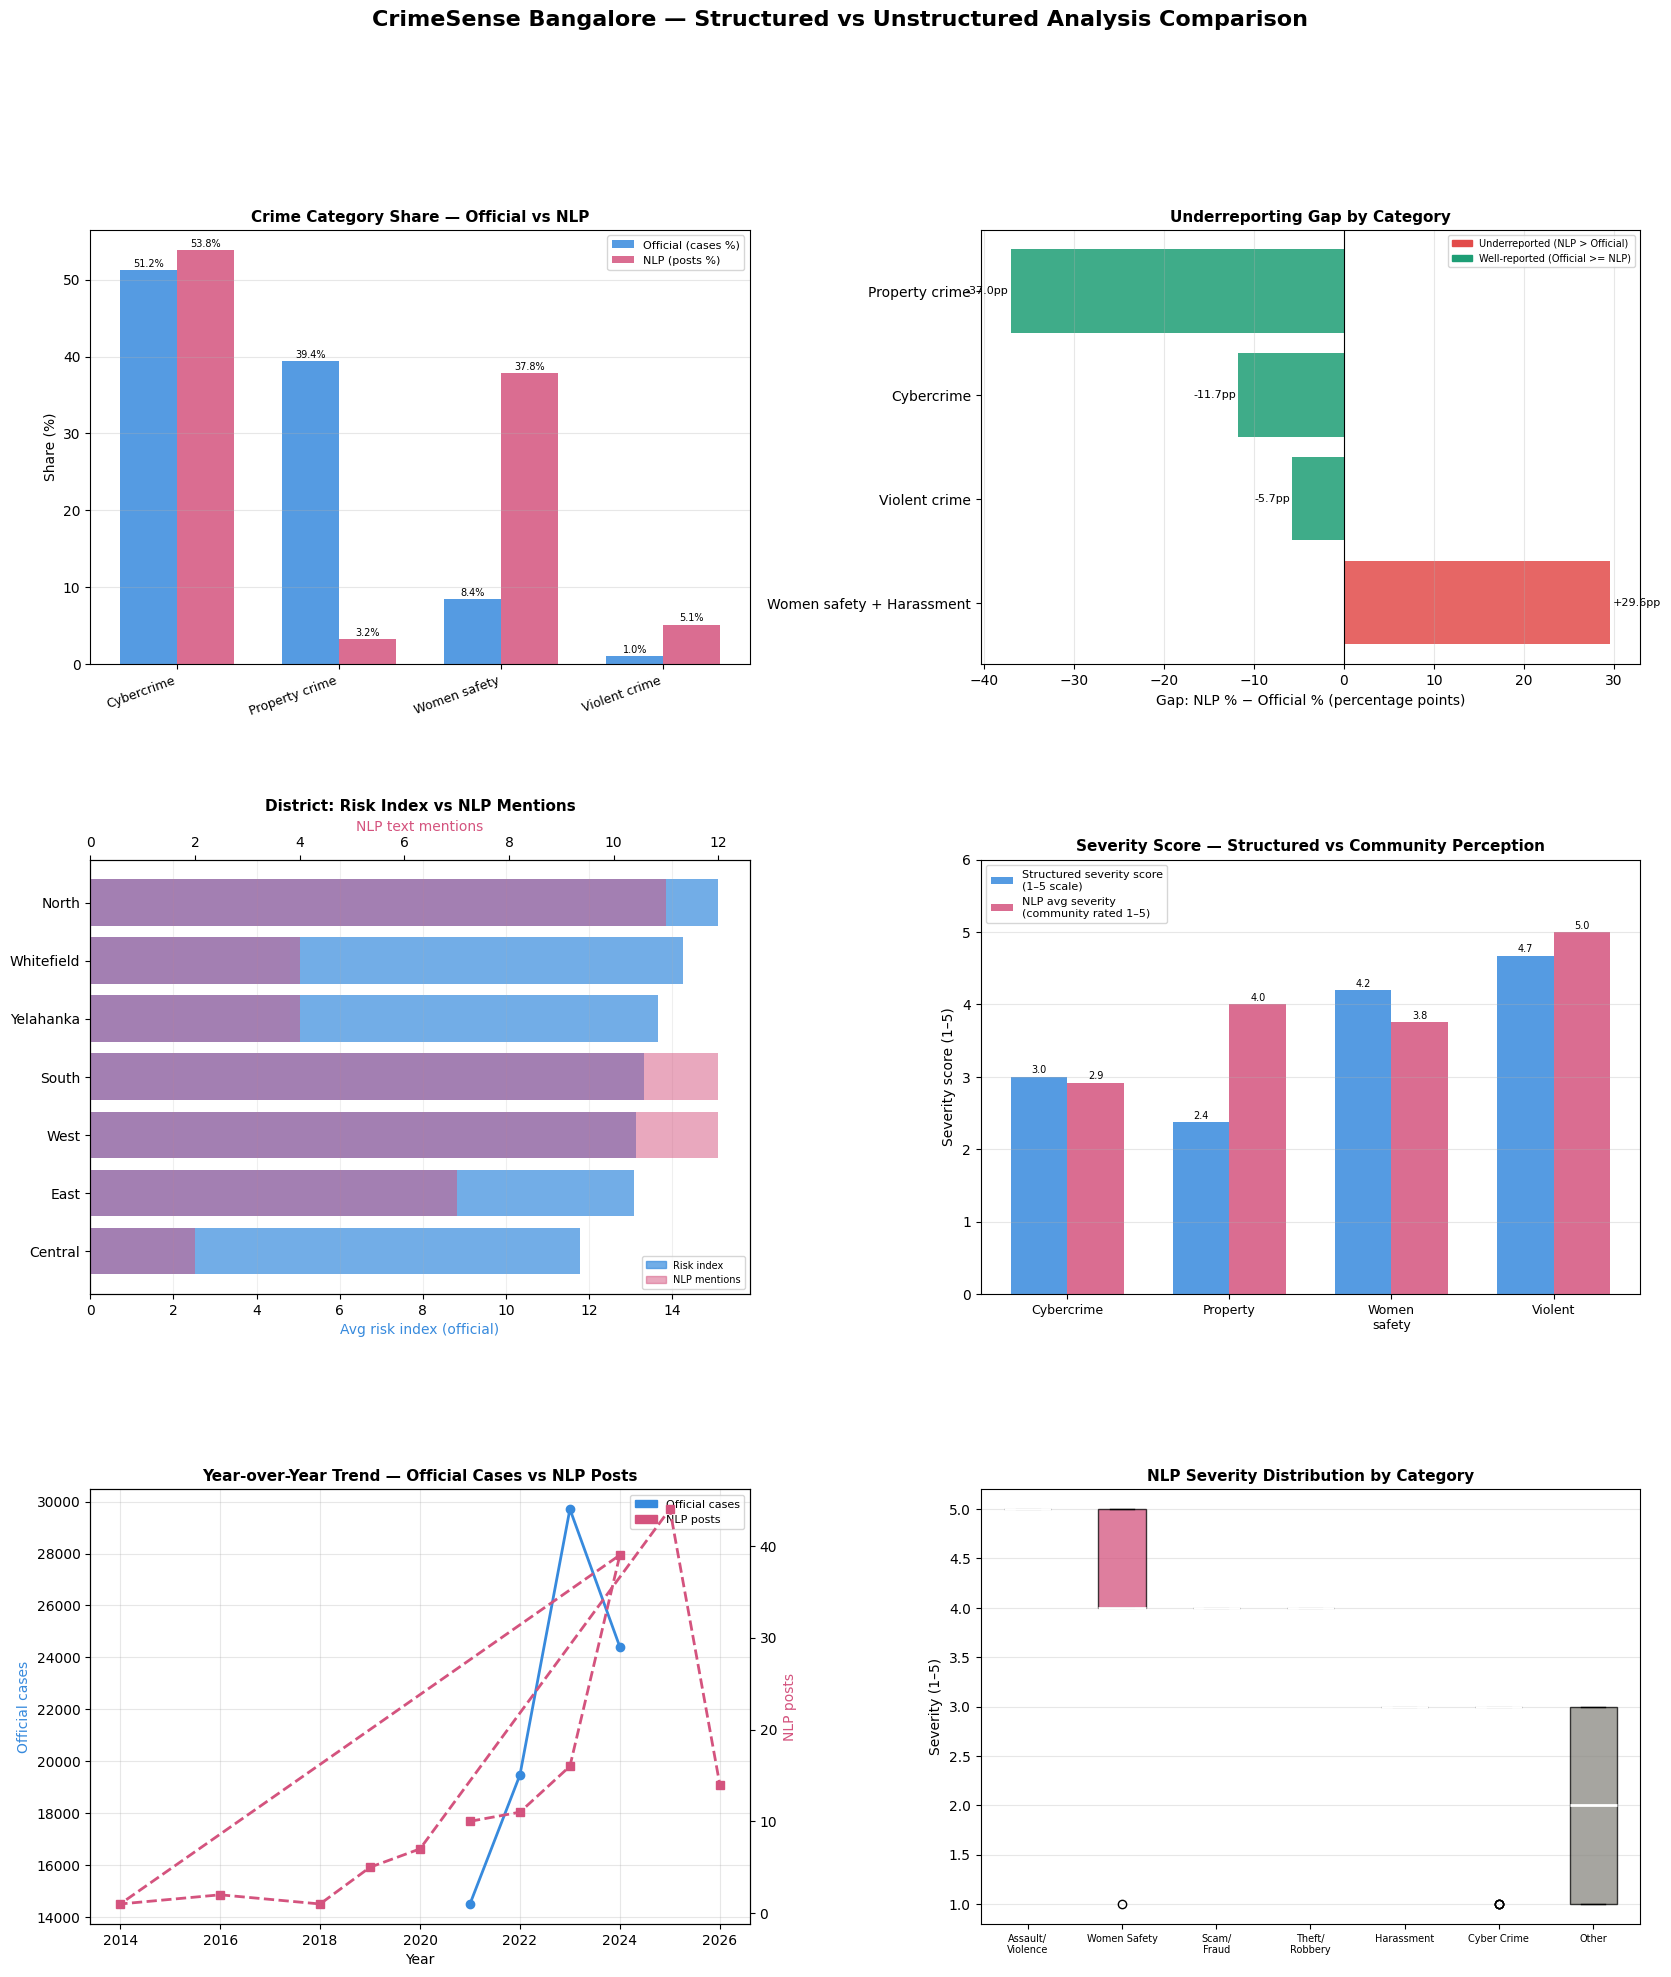

In [ ]:
# 10. PLOTS
# ─────────────────────────────────────────────

COLORS = {
    "official": "#378ADD",
    "nlp":      "#D4537E",
    "gap_pos":  "#E24B4A",
    "gap_neg":  "#1D9E75",
    "neutral":  "#888780",
}

fig = plt.figure(figsize=(20, 22))
fig.suptitle("CrimeSense Bangalore — Structured vs Unstructured Analysis Comparison",
             fontsize=16, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Category share side-by-side bar ──────────────────
ax1 = fig.add_subplot(gs[0, 0])

cats = ["cybercrime", "property_crime", "women_safety", "violent_crime"]
cat_labels = ["Cybercrime", "Property crime", "Women safety", "Violent crime"]
off_vals = [struct_share.get(c, 0) for c in cats]
nlp_vals = [nlp_share.get(c, 0) for c in cats]

x = np.arange(len(cats))
w = 0.35
ax1.bar(x - w/2, off_vals, w, label="Official (cases %)",  color=COLORS["official"], alpha=0.85)
ax1.bar(x + w/2, nlp_vals, w, label="NLP (posts %)",       color=COLORS["nlp"],      alpha=0.85)

ax1.set_xticks(x)
ax1.set_xticklabels(cat_labels, rotation=20, ha="right", fontsize=9)
ax1.set_ylabel("Share (%)")
ax1.set_title("Crime Category Share — Official vs NLP", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8)
ax1.grid(axis="y", alpha=0.3)

for bar in ax1.patches:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}%", ha="center", fontsize=7)

# ── Plot 2: Underreporting gap bar ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

gap_cats  = underreport["Category"].tolist()
gap_vals  = underreport["Gap (NLP%−Off%)"].tolist()
gap_colors = [COLORS["gap_pos"] if g > 0 else COLORS["gap_neg"] for g in gap_vals]

bars = ax2.barh(gap_cats, gap_vals, color=gap_colors, alpha=0.85)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Gap: NLP % − Official % (percentage points)")
ax2.set_title("Underreporting Gap by Category", fontsize=11, fontweight="bold")
ax2.grid(axis="x", alpha=0.3)

for bar, val in zip(bars, gap_vals):
    ax2.text(val + (0.3 if val >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
             f"{val:+.1f}pp", va="center", ha="left" if val >= 0 else "right", fontsize=8)

pos_patch = mpatches.Patch(color=COLORS["gap_pos"], label="Underreported (NLP > Official)")
neg_patch = mpatches.Patch(color=COLORS["gap_neg"], label="Well-reported (Official >= NLP)")
ax2.legend(handles=[pos_patch, neg_patch], fontsize=7)

# ── Plot 3: District risk index + NLP mentions ────────────────
ax3 = fig.add_subplot(gs[1, 0])

dist_sorted = dist_risk.sort_values("avg_risk_index", ascending=True)
districts   = dist_sorted.index.tolist()
risk_vals   = dist_sorted["avg_risk_index"].tolist()
nlp_m       = dist_sorted["nlp_mentions"].tolist()

ax3b = ax3.twiny()
ax3.barh(districts, risk_vals, color=COLORS["official"], alpha=0.7, label="Avg risk index")
ax3b.barh(districts, nlp_m,   color=COLORS["nlp"],      alpha=0.5, label="NLP mentions")

ax3.set_xlabel("Avg risk index (official)", color=COLORS["official"])
ax3b.set_xlabel("NLP text mentions", color=COLORS["nlp"])
ax3.set_title("District: Risk Index vs NLP Mentions", fontsize=11, fontweight="bold")
ax3.grid(axis="x", alpha=0.2)

p1 = mpatches.Patch(color=COLORS["official"], alpha=0.7, label="Risk index")
p2 = mpatches.Patch(color=COLORS["nlp"],      alpha=0.5, label="NLP mentions")
ax3.legend(handles=[p1, p2], fontsize=7, loc="lower right")

# ── Plot 4: Severity comparison ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])

sev_cats   = ["cybercrime", "property_crime", "women_safety", "violent_crime"]
sev_labels = ["Cybercrime", "Property", "Women\nsafety", "Violent"]
struct_sev_vals = [comp3.loc[c, "struct_sev_score"] if c in comp3.index else 0 for c in sev_cats]
nlp_sev_vals    = [comp3.loc[c, "nlp_avg_severity"]  if c in comp3.index else 0 for c in sev_cats]

x4 = np.arange(len(sev_cats))
ax4.bar(x4 - w/2, struct_sev_vals, w, label="Structured severity score\n(1–5 scale)", color=COLORS["official"], alpha=0.85)
ax4.bar(x4 + w/2, nlp_sev_vals,    w, label="NLP avg severity\n(community rated 1–5)", color=COLORS["nlp"],      alpha=0.85)

ax4.set_xticks(x4)
ax4.set_xticklabels(sev_labels, fontsize=9)
ax4.set_ylabel("Severity score (1–5)")
ax4.set_ylim(0, 6)
ax4.set_title("Severity Score — Structured vs Community Perception", fontsize=11, fontweight="bold")
ax4.legend(fontsize=8)
ax4.grid(axis="y", alpha=0.3)

for bar in ax4.patches:
    h = bar.get_height()
    if h > 0:
        ax4.text(bar.get_x() + bar.get_width()/2, h + 0.05, f"{h:.1f}", ha="center", fontsize=7)

# ── Plot 5: Year-over-year trend ──────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])

years_struct = comp4.index[comp4["official_cases"] > 0].tolist()
years_nlp    = comp4.index[comp4["nlp_posts"] > 0].tolist()

ax5_r = ax5.twinx()
ax5.plot(years_struct, comp4.loc[years_struct, "official_cases"],
         marker="o", color=COLORS["official"], linewidth=2, label="Official cases", markersize=6)
ax5_r.plot(years_nlp, comp4.loc[years_nlp, "nlp_posts"],
           marker="s", color=COLORS["nlp"],      linewidth=2, label="NLP posts",      markersize=6, linestyle="--")

ax5.set_xlabel("Year")
ax5.set_ylabel("Official cases",  color=COLORS["official"])
ax5_r.set_ylabel("NLP posts",     color=COLORS["nlp"])
ax5.set_title("Year-over-Year Trend — Official Cases vs NLP Posts", fontsize=11, fontweight="bold")
ax5.grid(alpha=0.3)

p1 = mpatches.Patch(color=COLORS["official"], label="Official cases")
p2 = mpatches.Patch(color=COLORS["nlp"],      label="NLP posts")
ax5.legend(handles=[p1, p2], fontsize=8)

# ── Plot 6: NLP severity by category (box) ───────────────────
ax6 = fig.add_subplot(gs[2, 1])

nlp_cats_ordered = ["Assault/Violence", "Women Safety", "Scam/Fraud", "Theft/Robbery", "Harassment", "Cyber Crime", "Other"]
nlp_cats_ordered = [c for c in nlp_cats_ordered if c in df_nlp["category"].values]

sev_data = [df_nlp[df_nlp["category"] == c]["severity"].values for c in nlp_cats_ordered]

bp = ax6.boxplot(sev_data, labels=[c.replace("/", "/\n") for c in nlp_cats_ordered],
                 patch_artist=True, medianprops=dict(color="white", linewidth=2))
colors6 = ["#E24B4A", "#D4537E", "#EF9F27", "#1D9E75", "#7F77DD", "#378ADD", "#888780"]
for patch, col in zip(bp["boxes"], colors6):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)

ax6.set_ylabel("Severity (1–5)")
ax6.set_title("NLP Severity Distribution by Category", fontsize=11, fontweight="bold")
ax6.grid(axis="y", alpha=0.3)
ax6.tick_params(axis="x", labelsize=7)

plt.savefig("crimesense_comparison_plots.png", dpi=150, bbox_inches="tight")
print("\n\nPlots saved → crimesense_comparison_plots.png")
plt.show()